# Healthcare Patient Analytics & Readmission Prediction

This notebook implements an end-to-end healthcare analytics pipeline that:

- ingests raw operational CSV extracts,
- cleans and standardizes patient, admission, vital, treatment, and doctor data,
- engineers analytical and machine learning features,
- builds a Power BI-friendly star schema,
- trains multiple readmission prediction models,
- generates probability-based risk scores, and
- persists warehouse tables to MySQL when connection settings are available.

The primary business grain for analytics is the **admission**. Readmission is defined as a subsequent admission for the same patient within **30 days** of discharge.

## A. Setup & Imports

This section prepares the notebook environment, validates package availability, and imports the libraries used across ETL, warehousing, modeling, visualization, and MySQL persistence.

In [1]:
import importlib
import json
import logging
import os
import pickle
import subprocess
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, List, Tuple

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sqlalchemy": "sqlalchemy",
    "pymysql": "pymysql",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}


def ensure_packages(package_map: Dict[str, str]) -> None:
    """Install any missing dependencies required by the notebook pipeline."""
    missing_packages: List[str] = []
    for module_name, package_name in package_map.items():
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing_packages.append(package_name)

    if missing_packages:
        print(f"Installing missing packages: {', '.join(missing_packages)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])


ensure_packages(REQUIRED_PACKAGES)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("healthcare_pipeline")

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Notebook working directory: %s", BASE_DIR)

Installing missing packages: xgboost


2026-03-17 20:59:41,622 | INFO | healthcare_pipeline | Notebook working directory: a:\INTERNSHIPS\Deloitte 2026\Online Internship\ADMM 4 weeks Case Studies\casestudy 8


## B. Data Loading

The notebook expects all source CSV files to live in the same working directory as the notebook. MySQL connectivity is configured through environment variables so credentials are not hardcoded into the analysis artifact.

Expected environment variables:

- `MYSQL_HOST`
- `MYSQL_PORT`
- `MYSQL_USER`
- `MYSQL_PASSWORD`
- `MYSQL_DATABASE`

If MySQL is unavailable at runtime, the notebook will still prepare all dimension and fact tables in-memory and clearly indicate that the load step should be rerun after connection details are provided.

In [2]:
CSV_FILES: Dict[str, str] = {
    "patients": "patients.csv",
    "admissions": "admissions.csv",
    "vitals": "vitals.csv",
    "treatments": "treatments.csv",
    "doctors": "doctors.csv",
}

MYSQL_CONFIG = {
    "host": os.getenv("MYSQL_HOST", os.getenv("DB_HOST", "127.0.0.1")),
    "port": int(os.getenv("MYSQL_PORT", os.getenv("DB_PORT", "3306"))),
    "user": os.getenv("MYSQL_USER", os.getenv("DB_USER", "root")),
    "password": os.getenv("MYSQL_PASSWORD", os.getenv("DB_PASS", "Monika#80")),
    "database": os.getenv("MYSQL_DATABASE", os.getenv("DB_NAME", "healthcare_dw")),
}


def make_one_hot_encoder() -> OneHotEncoder:
    """Create a version-compatible one-hot encoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)



def build_mysql_engine(config: Dict[str, Any]):
    """Create SQLAlchemy engine and ensure target MySQL database exists."""
    admin_url = URL.create(
        "mysql+pymysql",
        username=config["user"],
        password=config["password"],
        host=config["host"],
        port=config["port"],
    )

    admin_engine = create_engine(admin_url, pool_pre_ping=True, future=True)
    with admin_engine.begin() as connection:
        connection.execute(text(f"CREATE DATABASE IF NOT EXISTS `{config['database']}`"))

    database_url = URL.create(
        "mysql+pymysql",
        username=config["user"],
        password=config["password"],
        host=config["host"],
        port=config["port"],
        database=config["database"],
    )
    return create_engine(database_url, pool_pre_ping=True, future=True)



def initialize_mysql(config: Dict[str, Any]):
    """Initialize MySQL connection with fault-tolerant handling."""
    try:
        engine = build_mysql_engine(config)
        with engine.connect() as connection:
            connection.execute(text("SELECT 1"))
        logger.info("MySQL connection established for database: %s", config["database"])
        return engine, True
    except Exception as exc:
        logger.error("MySQL connection unavailable: %s", exc)
        return None, False



def extract_data(base_dir: Path, csv_map: Dict[str, str]) -> Dict[str, pd.DataFrame]:
    """Extract raw source datasets from CSV files."""
    extracted: Dict[str, pd.DataFrame] = {}
    for table_name, file_name in csv_map.items():
        file_path = base_dir / file_name
        if not file_path.exists():
            raise FileNotFoundError(f"Required source file not found: {file_path}")
        try:
            extracted[table_name] = pd.read_csv(file_path)
            logger.info("Extracted %s rows from %s", len(extracted[table_name]), file_name)
        except Exception as exc:
            logger.exception("Failed to extract %s: %s", file_name, exc)
            raise
    return extracted



def simulate_ehr_ingestion(patients_df: pd.DataFrame, admissions_df: pd.DataFrame, sample_size: int = 3) -> List[Dict[str, Any]]:
    """Simulate structured EHR ingestion messages using FHIR-style JSON payloads."""
    sample = admissions_df.merge(
        patients_df[["patient_id", "first_name", "last_name", "dob", "gender"]],
        on="patient_id",
        how="left",
    ).head(sample_size)

    messages: List[Dict[str, Any]] = []
    for _, row in sample.iterrows():
        messages.append(
            {
                "resourceType": "Bundle",
                "type": "message",
                "entry": [
                    {
                        "resource": {
                            "resourceType": "Patient",
                            "id": str(row["patient_id"]),
                            "name": [{"family": row.get("last_name", "Unknown"), "given": [row.get("first_name", "Unknown")]}],
                            "gender": str(row.get("gender", "unknown")).lower(),
                            "birthDate": str(row.get("dob", "")),
                        }
                    },
                    {
                        "resource": {
                            "resourceType": "Encounter",
                            "id": str(row["admission_id"]),
                            "period": {
                                "start": str(row.get("admission_date", "")),
                                "end": str(row.get("discharge_date", "")),
                            },
                            "reasonCode": [{"text": str(row.get("diagnosis", "Unknown"))}],
                        }
                    },
                ],
            }
        )
    return messages


mysql_engine, mysql_ready = initialize_mysql(MYSQL_CONFIG)
raw_data = extract_data(BASE_DIR, CSV_FILES)

patients = raw_data["patients"].copy()
admissions = raw_data["admissions"].copy()
vitals = raw_data["vitals"].copy()
treatments = raw_data["treatments"].copy()
doctors = raw_data["doctors"].copy()

raw_layer = {name: df.copy() for name, df in raw_data.items()}

ehr_messages = simulate_ehr_ingestion(patients, admissions)
print("Sample FHIR-like EHR ingestion payload:")
print(json.dumps(ehr_messages[0], indent=2)[:850] + "...")

source_summary = pd.DataFrame(
    {
        "table_name": list(raw_data.keys()),
        "rows": [len(df) for df in raw_data.values()],
        "columns": [df.shape[1] for df in raw_data.values()],
        "dataset_layer": "raw",
    }
)

display(source_summary)

2026-03-17 20:59:41,792 | INFO | healthcare_pipeline | MySQL connection established for database: healthcare_dw
2026-03-17 20:59:41,841 | INFO | healthcare_pipeline | Extracted 1690 rows from patients.csv
2026-03-17 20:59:41,878 | INFO | healthcare_pipeline | Extracted 3324 rows from admissions.csv
2026-03-17 20:59:41,962 | INFO | healthcare_pipeline | Extracted 33148 rows from vitals.csv
2026-03-17 20:59:42,005 | INFO | healthcare_pipeline | Extracted 8329 rows from treatments.csv
2026-03-17 20:59:42,032 | INFO | healthcare_pipeline | Extracted 40 rows from doctors.csv


Sample FHIR-like EHR ingestion payload:
{
  "resourceType": "Bundle",
  "type": "message",
  "entry": [
    {
      "resource": {
        "resourceType": "Patient",
        "id": "1001",
        "name": [
          {
            "family": "Kerr",
            "given": [
              "Stephen"
            ]
          }
        ],
        "gender": "female",
        "birthDate": "1976-12-15"
      }
    },
    {
      "resource": {
        "resourceType": "Encounter",
        "id": "2001",
        "period": {
          "start": "2026-02-07",
          "end": "2026-02-13"
        },
        "reasonCode": [
          {
            "text": "Diabetes Complication"
          }
        ]
      }
    }
  ]
}...


,table_name,rows,columns,dataset_layer
0,patients,1690,8,raw
1,admissions,3324,7,raw
2,vitals,33148,7,raw
3,treatments,8329,6,raw
4,doctors,40,5,raw


## C. Data Cleaning & Preprocessing

Data quality controls standardize date fields, remove duplicates, preserve healthcare identifiers, repair missing discharge dates, and split blood pressure into systolic and diastolic components for downstream analytics.

In [3]:
def split_blood_pressure(series: pd.Series) -> pd.DataFrame:
    """Split blood pressure strings into systolic and diastolic numeric columns."""
    cleaned = series.fillna("").astype(str).str.extract(r"(?P<systolic_bp>\d+)\s*/\s*(?P<diastolic_bp>\d+)")
    return cleaned.astype(float)



def validate_dataframes(admissions_df: pd.DataFrame, vitals_df: pd.DataFrame) -> pd.DataFrame:
    """Run validation checks for nulls, invalid ranges, and type consistency."""
    checks: List[Dict[str, Any]] = []

    checks.append(
        {
            "check_name": "missing_admission_date",
            "issue_count": int(admissions_df["admission_date"].isna().sum()),
            "severity": "high",
        }
    )
    checks.append(
        {
            "check_name": "missing_discharge_date",
            "issue_count": int(admissions_df["discharge_date"].isna().sum()),
            "severity": "high",
        }
    )

    invalid_oxygen = vitals_df["oxygen_level"].lt(70) | vitals_df["oxygen_level"].gt(100)
    invalid_hr = vitals_df["heart_rate"].lt(30) | vitals_df["heart_rate"].gt(220)
    invalid_temp = vitals_df["temperature"].lt(92) | vitals_df["temperature"].gt(108)

    checks.append(
        {
            "check_name": "invalid_oxygen_level_range_70_100",
            "issue_count": int(invalid_oxygen.fillna(False).sum()),
            "severity": "critical",
        }
    )
    checks.append(
        {
            "check_name": "invalid_heart_rate_range_30_220",
            "issue_count": int(invalid_hr.fillna(False).sum()),
            "severity": "critical",
        }
    )
    checks.append(
        {
            "check_name": "invalid_temperature_range_92_108",
            "issue_count": int(invalid_temp.fillna(False).sum()),
            "severity": "medium",
        }
    )

    checks.append(
        {
            "check_name": "missing_bp_components",
            "issue_count": int(vitals_df[["systolic_bp", "diastolic_bp"]].isna().any(axis=1).sum()),
            "severity": "medium",
        }
    )

    return pd.DataFrame(checks)



def transform_data(
    patients_df: pd.DataFrame,
    admissions_df: pd.DataFrame,
    vitals_df: pd.DataFrame,
    treatments_df: pd.DataFrame,
    doctors_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Transform raw datasets into cleaned, validated datasets."""
    raw_counts = {
        "patients": len(patients_df),
        "admissions": len(admissions_df),
        "vitals": len(vitals_df),
        "treatments": len(treatments_df),
        "doctors": len(doctors_df),
    }

    patients_df = patients_df.drop_duplicates().copy()
    admissions_df = admissions_df.drop_duplicates().copy()
    vitals_df = vitals_df.drop_duplicates().copy()
    treatments_df = treatments_df.drop_duplicates().copy()
    doctors_df = doctors_df.drop_duplicates().copy()

    id_columns_by_frame = [
        (patients_df, ["patient_id", "contact_no"]),
        (admissions_df, ["admission_id", "patient_id", "doctor_id"]),
        (vitals_df, ["vital_id", "admission_id"]),
        (treatments_df, ["treatment_id", "admission_id"]),
        (doctors_df, ["doctor_id", "contact_no"]),
    ]
    for dataframe, id_columns in id_columns_by_frame:
        for column in id_columns:
            if column in dataframe.columns:
                dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce").astype("Int64")

    patients_df["dob"] = pd.to_datetime(patients_df["dob"], errors="coerce")
    admissions_df["admission_date"] = pd.to_datetime(admissions_df["admission_date"], errors="coerce")
    admissions_df["discharge_date"] = pd.to_datetime(admissions_df["discharge_date"], errors="coerce")
    vitals_df["recorded_time"] = pd.to_datetime(vitals_df["recorded_time"], errors="coerce")
    treatments_df["treatment_date"] = pd.to_datetime(treatments_df["treatment_date"], errors="coerce")

    text_columns_by_frame = [
        (patients_df, ["first_name", "last_name", "gender", "address", "chronic_conditions"]),
        (admissions_df, ["diagnosis", "room_no"]),
        (vitals_df, ["blood_pressure"]),
        (treatments_df, ["procedure", "medication", "dosage"]),
        (doctors_df, ["first_name", "last_name", "specialization"]),
    ]
    for dataframe, text_columns in text_columns_by_frame:
        for column in text_columns:
            if column in dataframe.columns:
                dataframe[column] = dataframe[column].fillna("Unknown").astype(str).str.strip()

    bp_parts = split_blood_pressure(vitals_df["blood_pressure"])
    vitals_df = pd.concat([vitals_df, bp_parts], axis=1)

    numeric_vital_columns = ["heart_rate", "oxygen_level", "temperature", "systolic_bp", "diastolic_bp"]
    for column in numeric_vital_columns:
        vitals_df[column] = pd.to_numeric(vitals_df[column], errors="coerce")

    treatments_df["dosage_value_mg"] = pd.to_numeric(
        treatments_df["dosage"].str.extract(r"([\d.]+)", expand=False),
        errors="coerce",
    )

    latest_vital_date = vitals_df.groupby("admission_id", dropna=False)["recorded_time"].max().dt.normalize()
    latest_treatment_date = treatments_df.groupby("admission_id", dropna=False)["treatment_date"].max()

    admissions_df = admissions_df.merge(
        latest_vital_date.rename("latest_vital_date"),
        on="admission_id",
        how="left",
    ).merge(
        latest_treatment_date.rename("latest_treatment_date"),
        on="admission_id",
        how="left",
    )

    discharge_proxy = admissions_df[["admission_date", "latest_vital_date", "latest_treatment_date"]].max(axis=1)
    admissions_df["discharge_date"] = admissions_df["discharge_date"].fillna(discharge_proxy)
    admissions_df["discharge_date"] = admissions_df[["discharge_date", "admission_date"]].max(axis=1)
    admissions_df["length_of_stay"] = (
        (admissions_df["discharge_date"] - admissions_df["admission_date"]).dt.days.fillna(0).clip(lower=0)
    )

    admissions_df = admissions_df.drop(columns=["latest_vital_date", "latest_treatment_date"])

    quality_summary = pd.DataFrame(
        {
            "table_name": ["patients", "admissions", "vitals", "treatments", "doctors"],
            "duplicates_removed": [
                raw_counts["patients"] - len(patients_df),
                raw_counts["admissions"] - len(admissions_df),
                raw_counts["vitals"] - len(vitals_df),
                raw_counts["treatments"] - len(treatments_df),
                raw_counts["doctors"] - len(doctors_df),
            ],
        }
    )

    validation_report = validate_dataframes(admissions_df, vitals_df)
    logger.info("Transform completed with %s validation checks", len(validation_report))

    return patients_df, admissions_df, vitals_df, treatments_df, doctors_df, quality_summary, validation_report


patients_clean, admissions_clean, vitals_clean, treatments_clean, doctors_clean, quality_summary, validation_report = transform_data(
    patients,
    admissions,
    vitals,
    treatments,
    doctors,
)

cleaned_layer = {
    "patients": patients_clean,
    "admissions": admissions_clean,
    "vitals": vitals_clean,
    "treatments": treatments_clean,
    "doctors": doctors_clean,
}

display(quality_summary)
display(validation_report)
display(vitals_clean[["blood_pressure", "systolic_bp", "diastolic_bp"]].head())

2026-03-17 20:59:42,468 | INFO | healthcare_pipeline | Transform completed with 6 validation checks


,table_name,duplicates_removed
0,patients,0
1,admissions,0
2,vitals,0
3,treatments,0
4,doctors,0


,check_name,issue_count,severity
0,missing_admission_date,0,high
1,missing_discharge_date,0,high
2,invalid_oxygen_level_range_70_100,0,critical
3,invalid_heart_rate_range_30_220,0,critical
4,invalid_temperature_range_92_108,0,medium
5,missing_bp_components,0,medium


,blood_pressure,systolic_bp,diastolic_bp
0,129/81,129.0,81.0
1,130/71,130.0,71.0
2,134/73,134.0,73.0
3,121/70,121.0,70.0
4,131/85,131.0,85.0


## D. Feature Engineering

Feature engineering enriches each admission with clinically meaningful patient, vitals, treatment, and doctor context. The notebook also creates operational signals such as prior admissions, days since the previous discharge, and treatment intensity.

In [4]:
def create_readmission_target(admissions_df: pd.DataFrame) -> pd.DataFrame:
    """Generate binary readmission target based on 30-day revisit logic."""
    admissions_df = admissions_df.sort_values(["patient_id", "admission_date"]).copy()
    admissions_df["previous_discharge_date"] = admissions_df.groupby("patient_id")["discharge_date"].shift(1)
    admissions_df["days_since_previous_discharge"] = (
        admissions_df["admission_date"] - admissions_df["previous_discharge_date"]
    ).dt.days
    admissions_df["next_admission_date"] = admissions_df.groupby("patient_id")["admission_date"].shift(-1)
    admissions_df["days_to_next_admission"] = (
        admissions_df["next_admission_date"] - admissions_df["discharge_date"]
    ).dt.days
    admissions_df["prior_admissions"] = admissions_df.groupby("patient_id").cumcount()
    admissions_df["admission_sequence"] = admissions_df["prior_admissions"] + 1
    admissions_df["readmitted"] = admissions_df["days_to_next_admission"].between(0, 30, inclusive="both").astype(int)
    return admissions_df



def engineer_features(
    patients_df: pd.DataFrame,
    admissions_df: pd.DataFrame,
    vitals_df: pd.DataFrame,
    treatments_df: pd.DataFrame,
    doctors_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build processed feature layer for ML and readmission analytics."""
    admissions_enriched = create_readmission_target(admissions_df)

    vitals_df = vitals_df.copy()
    vitals_df["tachycardia_flag"] = (vitals_df["heart_rate"] > 100).astype(int)
    vitals_df["hypoxia_flag"] = (vitals_df["oxygen_level"] < 92).astype(int)
    vitals_df["fever_flag"] = (vitals_df["temperature"] >= 100.4).astype(int)

    vitals_agg = (
        vitals_df.groupby("admission_id")
        .agg(
            mean_heart_rate=("heart_rate", "mean"),
            min_oxygen_level=("oxygen_level", "min"),
            max_temperature=("temperature", "max"),
            mean_systolic_bp=("systolic_bp", "mean"),
            mean_diastolic_bp=("diastolic_bp", "mean"),
            tachycardia_events=("tachycardia_flag", "sum"),
            hypoxia_events=("hypoxia_flag", "sum"),
            fever_events=("fever_flag", "sum"),
            vital_records=("vital_id", "count"),
        )
        .reset_index()
    )

    treatment_agg = (
        treatments_df.groupby("admission_id")
        .agg(
            treatment_events=("treatment_id", "count"),
            unique_procedures=("procedure", "nunique"),
            unique_medications=("medication", "nunique"),
            avg_dosage_mg=("dosage_value_mg", "mean"),
        )
        .reset_index()
    )

    modeling_df = (
        admissions_enriched.merge(patients_df, on="patient_id", how="left", suffixes=("", "_patient"))
        .merge(doctors_df, on="doctor_id", how="left", suffixes=("", "_doctor"))
        .merge(vitals_agg, on="admission_id", how="left")
        .merge(treatment_agg, on="admission_id", how="left")
    )

    modeling_df["age_years"] = ((modeling_df["admission_date"] - modeling_df["dob"]).dt.days / 365.25).fillna(0).astype(int)
    modeling_df["age_years"] = modeling_df["age_years"].clip(lower=0)
    modeling_df["age_band"] = pd.cut(
        modeling_df["age_years"],
        bins=[-1, 17, 35, 50, 65, 80, np.inf],
        labels=["Child", "Young Adult", "Adult", "Mid Age", "Senior", "Elderly"],
    ).astype(str)
    modeling_df["has_chronic_condition"] = modeling_df["chronic_conditions"].ne("None").astype(int)
    modeling_df["weekend_admission"] = modeling_df["admission_date"].dt.dayofweek.isin([5, 6]).astype(int)
    modeling_df["admission_month"] = modeling_df["admission_date"].dt.month
    modeling_df["discharge_month"] = modeling_df["discharge_date"].dt.month
    modeling_df["days_since_previous_discharge"] = modeling_df["days_since_previous_discharge"].fillna(999)

    numeric_fill_columns = [
        "mean_heart_rate",
        "min_oxygen_level",
        "max_temperature",
        "mean_systolic_bp",
        "mean_diastolic_bp",
        "tachycardia_events",
        "hypoxia_events",
        "fever_events",
        "vital_records",
        "treatment_events",
        "unique_procedures",
        "unique_medications",
        "avg_dosage_mg",
    ]
    for column in numeric_fill_columns:
        if column in modeling_df.columns:
            modeling_df[column] = modeling_df[column].fillna(0)

    return admissions_enriched, vitals_agg, treatment_agg, modeling_df


admissions_features, vitals_agg, treatment_agg, modeling_dataset = engineer_features(
    patients_clean,
    admissions_clean,
    vitals_clean,
    treatments_clean,
    doctors_clean,
)

processed_layer = {
    "admissions_features": admissions_features,
    "vitals_agg": vitals_agg,
    "treatment_agg": treatment_agg,
    "modeling_dataset": modeling_dataset,
}

target_distribution = modeling_dataset["readmitted"].value_counts(dropna=False).rename_axis("readmitted").reset_index(name="count")
display(target_distribution)
display(modeling_dataset.head())

,readmitted,count
0,0,2956
1,1,368


,admission_id,patient_id,admission_date,discharge_date,diagnosis,doctor_id,room_no,length_of_stay,previous_discharge_date,days_since_previous_discharge,next_admission_date,days_to_next_admission,prior_admissions,admission_sequence,readmitted,first_name,last_name,dob,gender,contact_no,address,chronic_conditions,first_name_doctor,last_name_doctor,specialization,contact_no_doctor,mean_heart_rate,min_oxygen_level,max_temperature,mean_systolic_bp,mean_diastolic_bp,tachycardia_events,hypoxia_events,fever_events,vital_records,treatment_events,unique_procedures,unique_medications,avg_dosage_mg,age_years,age_band,has_chronic_condition,weekend_admission,admission_month,discharge_month
0,2001,1001,2026-02-07,2026-02-13,Diabetes Complication,317,R418,6,NaT,999.0,2026-03-07,22.0,0,1,1,Stephen,Kerr,1976-12-15,Female,1562097834,"84518 Jacob Knoll South Casey, WY 54234",Diabetes,Victoria,Kennedy,Endocrinologist,7306366394,91.000000,88,100.48,129.444444,83.000000,4,3,2,9,4,1,1,33.75,49,Adult,1,1,2,2
1,2002,1001,2026-03-07,2026-03-17,Heart Failure,320,R396,10,2026-02-13,22.0,NaT,NaN,1,2,0,Stephen,Kerr,1976-12-15,Female,1562097834,"84518 Jacob Knoll South Casey, WY 54234",Diabetes,Sheila,Rice,Cardiologist,8448335437,90.916667,88,100.85,119.916667,84.583333,4,5,3,12,1,1,1,25.00,49,Adult,1,1,3,3
2,2003,1002,2025-05-16,2025-05-21,Asthma Attack,339,R411,5,NaT,999.0,NaT,NaN,0,1,0,Jessica,Guzman,1964-06-11,Female,5669436555,"849 Deleon Island New Reginald, MS 05381",Asthma,Melissa,Barton,Pulmonologist,1013049199,83.866667,88,100.41,133.333333,82.133333,4,6,1,15,4,1,1,43.75,60,Mid Age,1,0,5,5
3,2005,1003,2025-08-11,2025-08-21,Pneumonia,306,R368,10,NaT,999.0,2025-12-08,109.0,0,1,0,Gary,Lewis,1939-09-03,Female,7199424360,"7876 Kimberly Burg Reedton, AK 55417",Unknown,Sarah,Johnson,Pulmonologist,3630144901,90.400000,89,100.86,134.100000,81.500000,2,2,2,10,2,1,1,30.00,85,Elderly,1,0,8,8
4,2004,1003,2025-12-08,2025-12-10,Respiratory Infection,325,R120,2,2025-08-21,109.0,NaT,NaN,1,2,0,Gary,Lewis,1939-09-03,Female,7199424360,"7876 Kimberly Burg Reedton, AK 55417",Unknown,James,Smith,Pulmonologist,8054928518,83.777778,88,100.60,139.555556,79.555556,3,5,1,9,2,1,1,37.50,86,Elderly,1,0,12,12


## E. Data Modeling (Warehouse Design)

A Power BI-friendly star schema is created using surrogate keys on dimensions and fact tables anchored on admissions, vitals, treatments, and model-driven readmission risk. This supports dashboard slicing by patient, doctor, diagnosis, time, and risk category.

In [5]:
def build_star_schema(
    patients_df: pd.DataFrame,
    doctors_df: pd.DataFrame,
    admissions_df: pd.DataFrame,
    vitals_df: pd.DataFrame,
    treatments_df: pd.DataFrame,
) -> Dict[str, pd.DataFrame]:
    """Build star schema tables for analytics and Power BI consumption."""
    dim_patients = patients_df.copy()
    dim_patients["patient_name"] = dim_patients["first_name"] + " " + dim_patients["last_name"]
    dim_patients["current_age"] = ((pd.Timestamp.today().normalize() - dim_patients["dob"]).dt.days / 365.25).fillna(0).astype(int)
    dim_patients["age_group"] = pd.cut(
        dim_patients["current_age"],
        bins=[-1, 17, 35, 50, 65, 80, np.inf],
        labels=["Child", "Young Adult", "Adult", "Mid Age", "Senior", "Elderly"],
    ).astype(str)
    dim_patients = dim_patients.sort_values("patient_id").reset_index(drop=True)
    dim_patients.insert(0, "patient_key", np.arange(1, len(dim_patients) + 1))
    dim_patients = dim_patients[
        [
            "patient_key",
            "patient_id",
            "patient_name",
            "dob",
            "current_age",
            "age_group",
            "gender",
            "contact_no",
            "address",
            "chronic_conditions",
        ]
    ]

    dim_doctors = doctors_df.copy()
    dim_doctors["doctor_name"] = dim_doctors["first_name"] + " " + dim_doctors["last_name"]
    dim_doctors = dim_doctors.sort_values("doctor_id").reset_index(drop=True)
    dim_doctors.insert(0, "doctor_key", np.arange(1, len(dim_doctors) + 1))
    dim_doctors = dim_doctors[
        [
            "doctor_key",
            "doctor_id",
            "doctor_name",
            "specialization",
            "contact_no",
        ]
    ]

    patient_bridge = dim_patients[["patient_id", "patient_key"]]
    doctor_bridge = dim_doctors[["doctor_id", "doctor_key"]]

    fact_admissions = admissions_df.merge(patient_bridge, on="patient_id", how="left").merge(
        doctor_bridge,
        on="doctor_id",
        how="left",
    )
    fact_admissions = fact_admissions.sort_values("admission_id").reset_index(drop=True)
    fact_admissions.insert(0, "admission_key", np.arange(1, len(fact_admissions) + 1))
    fact_admissions = fact_admissions[
        [
            "admission_key",
            "admission_id",
            "patient_key",
            "doctor_key",
            "patient_id",
            "doctor_id",
            "admission_date",
            "discharge_date",
            "length_of_stay",
            "diagnosis",
            "room_no",
            "prior_admissions",
            "days_since_previous_discharge",
            "next_admission_date",
            "days_to_next_admission",
            "readmitted",
        ]
    ]

    admission_bridge = fact_admissions[["admission_id", "admission_key", "patient_key"]]

    fact_vitals = vitals_df.merge(admission_bridge[["admission_id", "admission_key"]], on="admission_id", how="left")
    fact_vitals["vital_anomaly_flag"] = (
        (fact_vitals["oxygen_level"] < 88)
        | (fact_vitals["heart_rate"] > 140)
        | (fact_vitals["temperature"] >= 102)
    ).astype(int)
    fact_vitals = fact_vitals.sort_values("vital_id").reset_index(drop=True)
    fact_vitals.insert(0, "vital_key", np.arange(1, len(fact_vitals) + 1))
    fact_vitals = fact_vitals[
        [
            "vital_key",
            "vital_id",
            "admission_key",
            "admission_id",
            "recorded_time",
            "heart_rate",
            "systolic_bp",
            "diastolic_bp",
            "oxygen_level",
            "temperature",
            "vital_anomaly_flag",
        ]
    ]

    fact_treatments = treatments_df.merge(admission_bridge[["admission_id", "admission_key"]], on="admission_id", how="left")
    fact_treatments = fact_treatments.rename(columns={"procedure": "procedure_name"})
    fact_treatments = fact_treatments.sort_values("treatment_id").reset_index(drop=True)
    fact_treatments.insert(0, "treatment_key", np.arange(1, len(fact_treatments) + 1))
    fact_treatments = fact_treatments[
        [
            "treatment_key",
            "treatment_id",
            "admission_key",
            "admission_id",
            "treatment_date",
            "procedure_name",
            "medication",
            "dosage",
            "dosage_value_mg",
        ]
    ]

    return {
        "dim_patients": dim_patients,
        "dim_doctors": dim_doctors,
        "fact_admissions": fact_admissions,
        "fact_vitals": fact_vitals,
        "fact_treatments": fact_treatments,
    }


warehouse_tables = build_star_schema(
    patients_clean,
    doctors_clean,
    admissions_features,
    vitals_clean,
    treatments_clean,
)

schema_summary = pd.DataFrame(
    {
        "table_name": list(warehouse_tables.keys()),
        "rows": [len(df) for df in warehouse_tables.values()],
        "columns": [df.shape[1] for df in warehouse_tables.values()],
    }
)

display(schema_summary)

,table_name,rows,columns
0,dim_patients,1690,10
1,dim_doctors,40,5
2,fact_admissions,3324,16
3,fact_vitals,33148,11
4,fact_treatments,8329,9


## F. Data Merging for ML

The modeling layer uses a single admission-level dataset composed of patient demographics, chronic conditions, attending doctor specialization, aggregate vitals, treatment intensity, operational recency features, and the target variable defined in the next section.

## G. Target Variable Creation

A binary `readmitted` target is assigned when a patient has another admission within 30 days of the current discharge date. This aligns with a common hospital readmission KPI and provides a defensible operational definition for supervised learning.

## H. Machine Learning Models

Three classifiers are trained and benchmarked:

- Logistic Regression
- Random Forest
- XGBoost

Evaluation is based on accuracy, precision, recall, and F1-score. F1-score is used as the primary model selection metric because readmission prediction is typically more sensitive to class imbalance than raw accuracy alone.

2026-03-17 20:59:44,728 | INFO | healthcare_pipeline | Best model selected: XGBoost
2026-03-17 20:59:44,730 | INFO | healthcare_pipeline | Model artifact saved to: a:\INTERNSHIPS\Deloitte 2026\Online Internship\ADMM 4 weeks Case Studies\casestudy 8\artifacts\best_readmission_model.pkl


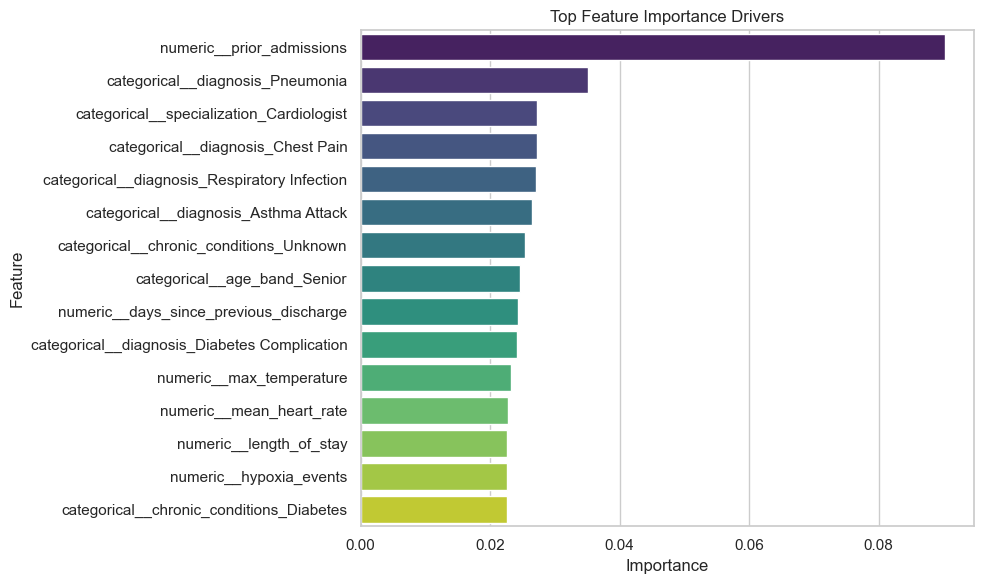

,model_name,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,0.887218,0.000000,0.000000,0.000000,0.641400
1,Random Forest,0.878195,0.266667,0.054054,0.089888,0.638656
2,Logistic Regression,0.509774,0.131579,0.608108,0.216346,0.592491


,metric,precision,recall,f1-score,support
0,0,0.888554,0.998308,0.940239,591.000000
1,1,0.000000,0.000000,0.000000,74.000000
2,accuracy,0.887218,0.887218,0.887218,0.887218
3,macro avg,0.444277,0.499154,0.470120,665.000000
4,weighted avg,0.789678,0.887218,0.835611,665.000000


,feature,importance,insight
2,numeric__prior_admissions,0.090235,Higher values of this feature have stronger in...
35,categorical__diagnosis_Pneumonia,0.035079,Higher values of this feature have stronger in...
37,categorical__specialization_Cardiologist,0.027332,Higher values of this feature have stronger in...
31,categorical__diagnosis_Chest Pain,0.027316,Higher values of this feature have stronger in...
36,categorical__diagnosis_Respiratory Infection,0.027081,Higher values of this feature have stronger in...
30,categorical__diagnosis_Asthma Attack,0.026505,Higher values of this feature have stronger in...
29,categorical__chronic_conditions_Unknown,0.025416,Higher values of this feature have stronger in...
45,categorical__age_band_Senior,0.024676,Higher values of this feature have stronger in...
3,numeric__days_since_previous_discharge,0.024380,Higher values of this feature have stronger in...
32,categorical__diagnosis_Diabetes Complication,0.024179,Higher values of this feature have stronger in...


In [ ]:
FEATURE_COLUMNS = [
    "age_years",
    "gender",
    "chronic_conditions",
    "diagnosis",
    "specialization",
    "length_of_stay",
    "prior_admissions",
    "days_since_previous_discharge",
    "mean_heart_rate",
    "min_oxygen_level",
    "max_temperature",
    "mean_systolic_bp",
    "mean_diastolic_bp",
    "tachycardia_events",
    "hypoxia_events",
    "fever_events",
    "vital_records",
    "treatment_events",
    "unique_procedures",
    "unique_medications",
    "avg_dosage_mg",
    "has_chronic_condition",
    "weekend_admission",
    "admission_month",
    "discharge_month",
    "age_band",
]
TARGET_COLUMN = "readmitted"
CATEGORICAL_FEATURES = [
    "gender",
    "chronic_conditions",
    "diagnosis",
    "specialization",
    "age_band",
]
NUMERIC_FEATURES = [column for column in FEATURE_COLUMNS if column not in CATEGORICAL_FEATURES]



def build_preprocessor() -> ColumnTransformer:
    """Create shared feature preprocessing transformer."""
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                NUMERIC_FEATURES,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                CATEGORICAL_FEATURES,
            ),
        ]
    )



def build_model_pipelines() -> Dict[str, Pipeline]:
    """Initialize all candidate models for model comparison."""
    return {
        "Logistic Regression": Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                ("scaler", StandardScaler(with_mean=False)),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000, 
                        class_weight="balanced", 
                        random_state=RANDOM_STATE),
                ),
            ]
        ),
        "Random Forest": Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=300,
                        max_depth=10,
                        min_samples_leaf=2,
                        random_state=RANDOM_STATE,
                        class_weight="balanced",
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "XGBoost": Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                (
                    "model",
                    XGBClassifier(
                        n_estimators=300,
                        max_depth=5,
                        learning_rate=0.05,
                        subsample=0.9,
                        colsample_bytree=0.9,
                        objective="binary:logistic",
                        eval_metric="logloss",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    }



def evaluate_models(modeling_df: pd.DataFrame) -> Dict[str, Any]:
    """Train and evaluate candidate models using enterprise evaluation metrics."""
    X = modeling_df[FEATURE_COLUMNS].copy()
    y = modeling_df[TARGET_COLUMN].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None,
    )

    pipelines = build_model_pipelines()
    fitted_models: Dict[str, Pipeline] = {}
    evaluation_rows: List[Dict[str, Any]] = []

    for model_name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        if hasattr(pipeline, "predict_proba"):
            probabilities = pipeline.predict_proba(X_test)[:, 1]
        else:
            probabilities = predictions.astype(float)

        evaluation_rows.append(
            {
                "model_name": model_name,
                "accuracy": accuracy_score(y_test, predictions),
                "precision": precision_score(y_test, predictions, zero_division=0),
                "recall": recall_score(y_test, predictions, zero_division=0),
                "f1_score": f1_score(y_test, predictions, zero_division=0),
                "roc_auc": roc_auc_score(y_test, probabilities),
            }
        )
        fitted_models[model_name] = pipeline

    metrics_df = pd.DataFrame(evaluation_rows).sort_values(
        by=["roc_auc", "f1_score", "recall", "precision", "accuracy"],
        ascending=False,
    ).reset_index(drop=True)

    best_model_name = metrics_df.loc[0, "model_name"]
    best_model = fitted_models[best_model_name]
    best_predictions = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        best_probabilities = best_model.predict_proba(X_test)[:, 1]
    else:
        best_probabilities = best_predictions.astype(float)

    model_artifact_path = ARTIFACT_DIR / "best_readmission_model.pkl"
    with open(model_artifact_path, "wb") as model_file:
        pickle.dump(best_model, model_file)

    logger.info("Best model selected: %s", best_model_name)
    logger.info("Model artifact saved to: %s", model_artifact_path)

    return {
        "X": X,
        "y": y,
        "X_test": X_test,
        "y_test": y_test,
        "metrics": metrics_df,
        "models": fitted_models,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "best_probabilities": best_probabilities,
        "best_classification_report": classification_report(y_test, best_predictions, zero_division=0, output_dict=True),
        "model_artifact_path": str(model_artifact_path),
    }



def plot_feature_importance(model_pipeline: Pipeline, top_n: int = 15) -> pd.DataFrame:
    """Generate explainability output using model coefficients/feature importances."""
    preprocessor = model_pipeline.named_steps["preprocessor"]
    estimator = model_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(estimator, "feature_importances_"):
        importance_values = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance_values = np.abs(estimator.coef_).ravel()
    else:
        return pd.DataFrame(columns=["feature", "importance"])

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importance_values})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
    plt.title("Top Feature Importance Drivers")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return importance_df


modeling_results = evaluate_models(modeling_dataset)
model_comparison = modeling_results["metrics"]
best_model_name = modeling_results["best_model_name"]
best_model = modeling_results["best_model"]
classification_report_df = pd.DataFrame(modeling_results["best_classification_report"]).transpose().reset_index().rename(columns={"index": "metric"})
feature_importance_df = plot_feature_importance(best_model)
explainability_insights = feature_importance_df.head(10).copy()
explainability_insights["insight"] = "Higher values of this feature have stronger influence on readmission prediction."

display(model_comparison)
display(classification_report_df)
display(explainability_insights)

## I. Risk Score Generation

The highest-performing model is used to produce a probability-based `risk_score` for every admission. Scores are translated into a business-friendly `risk_level` to support care management prioritization and dashboard filtering.

In [7]:
def classify_risk_level(score: float) -> str:
    """Classify risk score into operational care-risk buckets."""
    if score < 0.30:
        return "Low"
    if score < 0.65:
        return "Medium"
    return "High"



def risk_recommendation(row: pd.Series) -> str:
    """Generate actionable recommendation text based on risk profile."""
    if row["risk_level"] == "High":
        return "Schedule 48-hour follow-up, assign care coordinator, and enable daily remote monitoring."
    if row["risk_level"] == "Medium":
        return "Schedule 7-day follow-up and monitor medication adherence via nurse outreach."
    return "Standard discharge plan with routine follow-up and self-care education."


scored_admissions = modeling_dataset.copy()
scored_admissions["risk_score"] = best_model.predict_proba(scored_admissions[FEATURE_COLUMNS])[:, 1]
scored_admissions["predicted_readmitted"] = (scored_admissions["risk_score"] >= 0.5).astype(int)
scored_admissions["risk_level"] = scored_admissions["risk_score"].apply(classify_risk_level)
scored_admissions["risk_recommendation"] = scored_admissions.apply(risk_recommendation, axis=1)
scored_admissions["scored_at"] = pd.Timestamp.utcnow().tz_localize(None)

admission_keys = warehouse_tables["fact_admissions"][["admission_id", "admission_key", "patient_key"]].copy()
fact_readmission_risk = scored_admissions[
    [
        "admission_id",
        "patient_id",
        "readmitted",
        "predicted_readmitted",
        "risk_score",
        "risk_level",
        "risk_recommendation",
        "scored_at",
    ]
].merge(admission_keys, on="admission_id", how="left")

fact_readmission_risk = fact_readmission_risk.sort_values("admission_id").reset_index(drop=True)
fact_readmission_risk.insert(0, "risk_key", np.arange(1, len(fact_readmission_risk) + 1))
fact_readmission_risk["model_name"] = best_model_name
fact_readmission_risk = fact_readmission_risk[
    [
        "risk_key",
        "admission_key",
        "patient_key",
        "admission_id",
        "patient_id",
        "model_name",
        "readmitted",
        "predicted_readmitted",
        "risk_score",
        "risk_level",
        "risk_recommendation",
        "scored_at",
    ]
]

warehouse_tables["fact_readmission_risk"] = fact_readmission_risk

display(fact_readmission_risk.head())

,risk_key,admission_key,patient_key,admission_id,patient_id,model_name,readmitted,predicted_readmitted,risk_score,risk_level,risk_recommendation,scored_at
0,1,1,1,2001,1001,XGBoost,1,0,0.076648,Low,Standard discharge plan with routine follow-up...,2026-03-17 15:29:45.745283
1,2,2,1,2002,1001,XGBoost,0,0,0.051811,Low,Standard discharge plan with routine follow-up...,2026-03-17 15:29:45.745283
2,3,3,2,2003,1002,XGBoost,0,0,0.035300,Low,Standard discharge plan with routine follow-up...,2026-03-17 15:29:45.745283
3,4,4,3,2004,1003,XGBoost,0,0,0.027697,Low,Standard discharge plan with routine follow-up...,2026-03-17 15:29:45.745283
4,5,5,3,2005,1003,XGBoost,0,0,0.047690,Low,Standard discharge plan with routine follow-up...,2026-03-17 15:29:45.745283


## J. Load Data into MySQL

Dimension and fact tables are persisted to MySQL with replace semantics so the notebook can be rerun as a repeatable batch. Lightweight indexes are also created to improve analytical query performance for common dashboard access paths.

In [8]:
def create_core_mysql_tables(engine) -> None:
    """Create normalized core healthcare tables with PK/FK constraints."""
    ddl_statements = [
        """
        CREATE TABLE IF NOT EXISTS Doctors (
            doctor_id BIGINT PRIMARY KEY,
            first_name VARCHAR(100),
            last_name VARCHAR(100),
            specialization VARCHAR(120),
            contact_no VARCHAR(30)
        ) ENGINE=InnoDB
        """,
        """
        CREATE TABLE IF NOT EXISTS Patients (
            patient_id BIGINT PRIMARY KEY,
            first_name VARCHAR(100),
            last_name VARCHAR(100),
            dob DATE,
            gender VARCHAR(20),
            contact_no VARCHAR(30),
            address VARCHAR(255),
            chronic_conditions VARCHAR(255)
        ) ENGINE=InnoDB
        """,
        """
        CREATE TABLE IF NOT EXISTS Admissions (
            admission_id BIGINT PRIMARY KEY,
            patient_id BIGINT,
            admission_date DATETIME,
            discharge_date DATETIME,
            diagnosis VARCHAR(255),
            doctor_id BIGINT,
            room_no VARCHAR(30),
            length_of_stay INT,
            prior_admissions INT,
            days_since_previous_discharge INT,
            readmitted TINYINT,
            INDEX idx_admissions_patient_id (patient_id),
            INDEX idx_admissions_doctor_id (doctor_id),
            CONSTRAINT fk_admissions_patient FOREIGN KEY (patient_id) REFERENCES Patients(patient_id),
            CONSTRAINT fk_admissions_doctor FOREIGN KEY (doctor_id) REFERENCES Doctors(doctor_id)
        ) ENGINE=InnoDB
        """,
        """
        CREATE TABLE IF NOT EXISTS Vitals (
            vital_id BIGINT PRIMARY KEY,
            admission_id BIGINT,
            recorded_time DATETIME,
            heart_rate DOUBLE,
            systolic_bp DOUBLE,
            diastolic_bp DOUBLE,
            oxygen_level DOUBLE,
            temperature DOUBLE,
            INDEX idx_vitals_admission_id (admission_id),
            CONSTRAINT fk_vitals_admission FOREIGN KEY (admission_id) REFERENCES Admissions(admission_id)
        ) ENGINE=InnoDB
        """,
        """
        CREATE TABLE IF NOT EXISTS Treatments (
            treatment_id BIGINT PRIMARY KEY,
            admission_id BIGINT,
            treatment_date DATETIME,
            procedure_name VARCHAR(255),
            medication VARCHAR(255),
            dosage VARCHAR(100),
            dosage_value_mg DOUBLE,
            INDEX idx_treatments_admission_id (admission_id),
            CONSTRAINT fk_treatments_admission FOREIGN KEY (admission_id) REFERENCES Admissions(admission_id)
        ) ENGINE=InnoDB
        """,
        """
        CREATE TABLE IF NOT EXISTS Readmission_Risk (
            risk_key BIGINT PRIMARY KEY,
            admission_id BIGINT,
            patient_id BIGINT,
            model_name VARCHAR(120),
            readmitted TINYINT,
            predicted_readmitted TINYINT,
            risk_score DOUBLE,
            risk_level VARCHAR(20),
            risk_recommendation VARCHAR(500),
            scored_at DATETIME,
            INDEX idx_risk_admission_id (admission_id),
            INDEX idx_risk_level (risk_level),
            CONSTRAINT fk_risk_admission FOREIGN KEY (admission_id) REFERENCES Admissions(admission_id),
            CONSTRAINT fk_risk_patient FOREIGN KEY (patient_id) REFERENCES Patients(patient_id)
        ) ENGINE=InnoDB
        """,
    ]

    with engine.begin() as connection:
        connection.execute(text("SET FOREIGN_KEY_CHECKS=0"))
        for table_name in ["Readmission_Risk", "Treatments", "Vitals", "Admissions", "Patients", "Doctors"]:
            connection.execute(text(f"DROP TABLE IF EXISTS {table_name}"))
        connection.execute(text("SET FOREIGN_KEY_CHECKS=1"))
        for statement in ddl_statements:
            connection.execute(text(statement))



def batch_insert_to_mysql(engine, table_name: str, dataframe: pd.DataFrame, chunksize: int = 1000) -> None:
    """Insert dataframe into MySQL table using chunked multi-row inserts."""
    dataframe.to_sql(table_name, engine, if_exists="append", index=False, method="multi", chunksize=chunksize)



def load_data(engine, clean_tables: Dict[str, pd.DataFrame], star_tables: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Load normalized and star-schema datasets into MySQL with audit logging."""
    if engine is None:
        raise ValueError("MySQL engine is not initialized")

    create_core_mysql_tables(engine)

    doctors_load = clean_tables["doctors"].copy()
    patients_load = clean_tables["patients"].copy()
    admissions_load = star_tables["fact_admissions"].copy()
    vitals_load = clean_tables["vitals"].copy()
    treatments_load = clean_tables["treatments"].rename(columns={"procedure": "procedure_name"}).copy()
    risk_load = star_tables["fact_readmission_risk"].copy()

    admissions_load = admissions_load[
        [
            "admission_id",
            "patient_id",
            "admission_date",
            "discharge_date",
            "diagnosis",
            "doctor_id",
            "room_no",
            "length_of_stay",
            "prior_admissions",
            "days_since_previous_discharge",
            "readmitted",
        ]
    ]

    vitals_load = vitals_load[
        [
            "vital_id",
            "admission_id",
            "recorded_time",
            "heart_rate",
            "systolic_bp",
            "diastolic_bp",
            "oxygen_level",
            "temperature",
        ]
    ]

    treatments_load = treatments_load[
        [
            "treatment_id",
            "admission_id",
            "treatment_date",
            "procedure_name",
            "medication",
            "dosage",
            "dosage_value_mg",
        ]
    ]

    risk_load = risk_load[
        [
            "risk_key",
            "admission_id",
            "patient_id",
            "model_name",
            "readmitted",
            "predicted_readmitted",
            "risk_score",
            "risk_level",
            "risk_recommendation",
            "scored_at",
        ]
    ]

    load_plan = [
        ("Doctors", doctors_load),
        ("Patients", patients_load),
        ("Admissions", admissions_load),
        ("Vitals", vitals_load),
        ("Treatments", treatments_load),
        ("Readmission_Risk", risk_load),
    ]

    audit_rows: List[Dict[str, Any]] = []
    for table_name, df in load_plan:
        batch_insert_to_mysql(engine, table_name, df)
        audit_rows.append({"table_name": table_name, "rows_loaded": len(df)})
        logger.info("Loaded %s rows into %s", len(df), table_name)

    for table_name, dataframe in star_tables.items():
        dataframe.to_sql(table_name, engine, if_exists="replace", index=False, method="multi", chunksize=1000)

    index_statements = [
        "CREATE INDEX idx_fact_admissions_patient_key ON fact_admissions (patient_key)",
        "CREATE INDEX idx_fact_admissions_doctor_key ON fact_admissions (doctor_key)",
        "CREATE INDEX idx_fact_admissions_admission_date ON fact_admissions (admission_date)",
        "CREATE INDEX idx_fact_vitals_admission_key ON fact_vitals (admission_key)",
        "CREATE INDEX idx_fact_treatments_admission_key ON fact_treatments (admission_key)",
        "CREATE INDEX idx_fact_readmission_risk_admission_key ON fact_readmission_risk (admission_key)",
        "CREATE INDEX idx_fact_readmission_risk_risk_level ON fact_readmission_risk (risk_level)",
    ]

    with engine.begin() as connection:
        for statement in index_statements:
            try:
                connection.execute(text(statement))
            except Exception:
                pass

    return pd.DataFrame(audit_rows)


if mysql_ready:
    mysql_load_summary = load_data(mysql_engine, cleaned_layer, warehouse_tables)
    display(mysql_load_summary)
else:
    mysql_load_summary = pd.DataFrame(
        {
            "table_name": ["Doctors", "Patients", "Admissions", "Vitals", "Treatments", "Readmission_Risk"],
            "status": "Prepared in-memory; rerun after configuring MySQL",
        }
    )
    display(mysql_load_summary)

2026-03-17 20:59:46,196 | INFO | healthcare_pipeline | Loaded 40 rows into Doctors
2026-03-17 20:59:46,337 | INFO | healthcare_pipeline | Loaded 1690 rows into Patients
2026-03-17 20:59:46,708 | INFO | healthcare_pipeline | Loaded 3324 rows into Admissions
2026-03-17 20:59:48,984 | INFO | healthcare_pipeline | Loaded 33148 rows into Vitals
2026-03-17 20:59:49,621 | INFO | healthcare_pipeline | Loaded 8329 rows into Treatments
2026-03-17 20:59:50,029 | INFO | healthcare_pipeline | Loaded 3324 rows into Readmission_Risk


,table_name,rows_loaded
0,Doctors,40
1,Patients,1690
2,Admissions,3324
3,Vitals,33148
4,Treatments,8329
5,Readmission_Risk,3324


## K. SQL Analytics Section

These SQL queries can be executed directly against MySQL after the warehouse load completes. They support common healthcare operations and executive reporting use cases.

## L. Power BI Ready Layer

The final star schema is optimized for Power BI as follows:

- `dim_patients` and `dim_doctors` act as slicer-friendly dimensions.
- `fact_admissions` is the core admission-level fact for trends, LOS, diagnosis, and readmission KPIs.
- `fact_vitals` supports drill-through detail and vital trend analysis.
- `fact_treatments` supports treatment utilization dashboards.
- `fact_readmission_risk` supports high-risk cohort monitoring, intervention prioritization, and predictive KPI cards.

Recommended Power BI relationships:

- `dim_patients.patient_key` -> `fact_admissions.patient_key`
- `dim_doctors.doctor_key` -> `fact_admissions.doctor_key`
- `fact_admissions.admission_key` -> `fact_vitals.admission_key`
- `fact_admissions.admission_key` -> `fact_treatments.admission_key`
- `fact_admissions.admission_key` -> `fact_readmission_risk.admission_key`

In [9]:
SQL_QUERIES = {
    "Daily admissions and discharges": """
        SELECT
            DATE(admission_date) AS event_date,
            COUNT(*) AS daily_admissions,
            SUM(CASE WHEN discharge_date IS NOT NULL THEN 1 ELSE 0 END) AS daily_discharges
        FROM Admissions
        GROUP BY DATE(admission_date)
        ORDER BY event_date;
    """,
    "Readmission rate analysis": """
        SELECT
            ROUND(100 * AVG(readmitted), 2) AS readmission_rate_pct,
            COUNT(*) AS total_admissions
        FROM Admissions;
    """,
    "High-risk patient identification": """
        SELECT
            rr.patient_id,
            p.first_name,
            p.last_name,
            rr.risk_score,
            rr.risk_level,
            rr.risk_recommendation
        FROM Readmission_Risk rr
        JOIN Patients p ON rr.patient_id = p.patient_id
        WHERE rr.risk_level = 'High'
        ORDER BY rr.risk_score DESC
        LIMIT 100;
    """,
    "Average LOS by diagnosis": """
        SELECT
            diagnosis,
            ROUND(AVG(length_of_stay), 2) AS avg_los_days,
            COUNT(*) AS admissions
        FROM Admissions
        GROUP BY diagnosis
        ORDER BY avg_los_days DESC;
    """,
    "Vitals anomaly detection": """
        SELECT
            v.admission_id,
            AVG(v.heart_rate) AS avg_heart_rate,
            MIN(v.oxygen_level) AS min_oxygen,
            MAX(v.temperature) AS max_temperature,
            SUM(CASE WHEN v.oxygen_level < 88 OR v.heart_rate > 140 OR v.temperature >= 102 THEN 1 ELSE 0 END) AS anomaly_points
        FROM Vitals v
        GROUP BY v.admission_id
        HAVING anomaly_points > 0
        ORDER BY anomaly_points DESC, min_oxygen ASC;
    """,
}

for query_name, query_text in SQL_QUERIES.items():
    print(f"\n{query_name}\n{'-' * len(query_name)}")
    print(query_text.strip())

if mysql_ready:
    sql_results = {}
    for query_name, query_text in SQL_QUERIES.items():
        sql_results[query_name] = pd.read_sql(query_text, mysql_engine)

    for query_name, result_df in sql_results.items():
        display(Markdown(f"### {query_name}"))
        display(result_df)
else:
    print("SQL execution skipped because MySQL is not currently available from this notebook session.")

power_bi_table_guide = pd.DataFrame(
    [
        ["Patients", "Core", "Patient demographics and chronic-condition segmentation"],
        ["Doctors", "Core", "Provider and specialization performance analytics"],
        ["Admissions", "Core", "Admission/discharge trends and LOS/readmission KPIs"],
        ["Vitals", "Core", "Clinical anomaly monitoring and deterioration trends"],
        ["Treatments", "Core", "Procedure and medication utilization"],
        ["Readmission_Risk", "Core", "Operational risk stratification and intervention planning"],
        ["dim_patients", "Dimension", "Power BI slicers and patient drill-down"],
        ["dim_doctors", "Dimension", "Provider drill-down and hierarchy analysis"],
        ["fact_admissions", "Fact", "Admission-grain analytics for KPI cards and time series"],
        ["fact_vitals", "Fact", "Vitals drill-through and anomaly trend charts"],
        ["fact_treatments", "Fact", "Treatment utilization by diagnosis/provider"],
        ["fact_readmission_risk", "Fact", "Predictive risk dashboard and care recommendations"],
    ],
    columns=["table_name", "layer_type", "dashboard_usage"],
)

index_recommendations = pd.DataFrame(
    [
        ["Admissions", "patient_id, admission_date", "Speeds patient timeline and readmission analysis"],
        ["Admissions", "diagnosis", "Improves LOS-by-diagnosis aggregations"],
        ["Vitals", "admission_id, recorded_time", "Improves anomaly and trend detection queries"],
        ["Readmission_Risk", "risk_level, risk_score", "Improves high-risk patient triage"],
        ["fact_admissions", "patient_key", "Improves Power BI slicing by patient dimension"],
        ["fact_readmission_risk", "risk_level", "Improves predictive risk filtering in reports"],
    ],
    columns=["table_name", "index_column", "rationale"],
)

display(power_bi_table_guide)
display(index_recommendations)


Daily admissions and discharges
-------------------------------
SELECT
            DATE(admission_date) AS event_date,
            COUNT(*) AS daily_admissions,
            SUM(CASE WHEN discharge_date IS NOT NULL THEN 1 ELSE 0 END) AS daily_discharges
        FROM Admissions
        GROUP BY DATE(admission_date)
        ORDER BY event_date;

Readmission rate analysis
-------------------------
SELECT
            ROUND(100 * AVG(readmitted), 2) AS readmission_rate_pct,
            COUNT(*) AS total_admissions
        FROM Admissions;

High-risk patient identification
--------------------------------
SELECT
            rr.patient_id,
            p.first_name,
            p.last_name,
            rr.risk_score,
            rr.risk_level,
            rr.risk_recommendation
        FROM Readmission_Risk rr
        JOIN Patients p ON rr.patient_id = p.patient_id
        WHERE rr.risk_level = 'High'
        ORDER BY rr.risk_score DESC
        LIMIT 100;

Average LOS by diagnosis
------------

### Daily admissions and discharges

,event_date,daily_admissions,daily_discharges
0,2025-03-11,11,11.0
1,2025-03-12,8,8.0
2,2025-03-13,7,7.0
3,2025-03-14,5,5.0
4,2025-03-15,9,9.0
...,...,...,...
361,2026-03-07,12,12.0
362,2026-03-08,12,12.0
363,2026-03-09,6,6.0
364,2026-03-10,18,18.0


### Readmission rate analysis

,readmission_rate_pct,total_admissions
0,11.07,3324


...

,diagnosis,avg_los_days,admissions
0,Chest Pain,6.09,485
1,Respiratory Infection,6.06,689
2,Hypertension,6.05,746
3,Heart Failure,5.88,473
4,Pneumonia,5.84,454
5,Diabetes Complication,5.80,225
6,Asthma Attack,5.77,252


### Vitals anomaly detection

,admission_id,avg_heart_rate,min_oxygen,max_temperature,anomaly_points


,table_name,layer_type,dashboard_usage
0,Patients,Core,Patient demographics and chronic-condition seg...
1,Doctors,Core,Provider and specialization performance analytics
2,Admissions,Core,Admission/discharge trends and LOS/readmission...
3,Vitals,Core,Clinical anomaly monitoring and deterioration ...
4,Treatments,Core,Procedure and medication utilization
5,Readmission_Risk,Core,Operational risk stratification and interventi...
6,dim_patients,Dimension,Power BI slicers and patient drill-down
7,dim_doctors,Dimension,Provider drill-down and hierarchy analysis
8,fact_admissions,Fact,Admission-grain analytics for KPI cards and ti...
9,fact_vitals,Fact,Vitals drill-through and anomaly trend charts


,table_name,index_column,rationale
0,Admissions,"patient_id, admission_date",Speeds patient timeline and readmission analysis
1,Admissions,diagnosis,Improves LOS-by-diagnosis aggregations
2,Vitals,"admission_id, recorded_time",Improves anomaly and trend detection queries
3,Readmission_Risk,"risk_level, risk_score",Improves high-risk patient triage
4,fact_admissions,patient_key,Improves Power BI slicing by patient dimension
5,fact_readmission_risk,risk_level,Improves predictive risk filtering in reports


## M. Enhancement Layer (Non-breaking Extensions)

The following cells extend the current pipeline without changing the existing structure. They add explicit validation, model comparison visibility, best-model selection details, vitals risk flags, post-discharge follow-up logic, and optimized SQL query snippets.

In [10]:
def validate_for_modeling(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Validate and clean modeling data before training.

    Checks:
    - Missing/null values
    - oxygen_level range (70-100)
    - heart_rate range (40-180)
    """
    candidate = df.copy()

    # Build a validation report with explicit counts for auditability.
    validation_rows: List[Dict[str, Any]] = []
    validation_rows.append(
        {
            "check": "nulls_in_key_features",
            "issue_count": int(candidate[FEATURE_COLUMNS].isna().sum().sum()),
        }
    )

    invalid_oxygen_mask = (candidate["min_oxygen_level"] < 70) | (candidate["min_oxygen_level"] > 100)
    invalid_hr_mask = (candidate["mean_heart_rate"] < 40) | (candidate["mean_heart_rate"] > 180)

    validation_rows.append(
        {
            "check": "invalid_min_oxygen_level_range_70_100",
            "issue_count": int(invalid_oxygen_mask.fillna(False).sum()),
        }
    )
    validation_rows.append(
        {
            "check": "invalid_mean_heart_rate_range_40_180",
            "issue_count": int(invalid_hr_mask.fillna(False).sum()),
        }
    )

    # Handle invalid values: replace with NaN and impute using medians.
    candidate.loc[invalid_oxygen_mask, "min_oxygen_level"] = np.nan
    candidate.loc[invalid_hr_mask, "mean_heart_rate"] = np.nan

    for col in NUMERIC_FEATURES:
        candidate[col] = candidate[col].fillna(candidate[col].median())

    validation_df = pd.DataFrame(validation_rows)
    return candidate, validation_df



def add_vital_risk_flag(vitals_df: pd.DataFrame) -> pd.DataFrame:
    """Flag abnormal vital readings into operational risk categories."""
    tagged = vitals_df.copy()
    tagged["vital_risk_flag"] = "Normal"
    tagged.loc[tagged["oxygen_level"] < 90, "vital_risk_flag"] = "Critical"
    tagged.loc[(tagged["oxygen_level"] >= 90) & (tagged["heart_rate"] > 120), "vital_risk_flag"] = "High Risk"
    return tagged


modeling_dataset_validated, pre_model_validation_report = validate_for_modeling(modeling_dataset)
vitals_enhanced = add_vital_risk_flag(vitals_clean)

print("Pre-model validation summary:")
display(pre_model_validation_report)
print("Vitals risk flag distribution:")
display(vitals_enhanced["vital_risk_flag"].value_counts().rename_axis("vital_risk_flag").reset_index(name="count"))

Pre-model validation summary:


,check,issue_count
0,nulls_in_key_features,0
1,invalid_min_oxygen_level_range_70_100,0
2,invalid_mean_heart_rate_range_40_180,0


Vitals risk flag distribution:


,vital_risk_flag,count
0,Normal,27920
1,Critical,5228


In [11]:
def evaluate_and_compare_models(modeling_df: pd.DataFrame) -> Tuple[pd.DataFrame, str, Pipeline, Dict[str, Pipeline]]:
    """Train all models and return a comparison table plus best model selected by ROC-AUC."""
    X = modeling_df[FEATURE_COLUMNS].copy()
    y = modeling_df[TARGET_COLUMN].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None,
    )

    models = build_model_pipelines()
    rows: List[Dict[str, Any]] = []

    for model_name, pipeline in models.items():
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, "predict_proba") else y_pred.astype(float)

        rows.append(
            {
                "model_name": model_name,
                "accuracy": accuracy_score(y_test, y_pred),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, y_prob),
            }
        )

    comparison = pd.DataFrame(rows).sort_values(by=["roc_auc", "recall", "precision", "accuracy"], ascending=False).reset_index(drop=True)
    selected_name = comparison.loc[0, "model_name"]
    selected_model = models[selected_name]

    print("Model performance comparison:")
    display(comparison)
    print(f"Best model selected: {selected_name} (highest ROC-AUC = {comparison.loc[0, 'roc_auc']:.4f})")

    return comparison, selected_name, selected_model, models



def extract_feature_explainability(model_pipeline: Pipeline, top_n: int = 10) -> pd.DataFrame:
    """Extract top feature drivers using model feature_importances_ or coefficients."""
    preprocessor = model_pipeline.named_steps["preprocessor"]
    model = model_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    # Tree-based models expose feature_importances_, linear models use coefficients.
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_).ravel()
    else:
        return pd.DataFrame(columns=["feature", "importance"])

    explain_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    print(f"Top {top_n} feature drivers:")
    display(explain_df)
    return explain_df


enhanced_model_comparison, enhanced_best_model_name, best_model, trained_models = evaluate_and_compare_models(modeling_dataset_validated)
enhanced_feature_importance = extract_feature_explainability(best_model, top_n=10)

Model performance comparison:


,model_name,accuracy,precision,recall,roc_auc
0,XGBoost,0.887218,0.000000,0.000000,0.641400
1,Random Forest,0.878195,0.266667,0.054054,0.638656
2,Logistic Regression,0.509774,0.131579,0.608108,0.592491


Best model selected: XGBoost (highest ROC-AUC = 0.6414)
Top 10 feature drivers:


,feature,importance
0,numeric__prior_admissions,0.090235
1,categorical__diagnosis_Pneumonia,0.035079
2,categorical__specialization_Cardiologist,0.027332
3,categorical__diagnosis_Chest Pain,0.027316
4,categorical__diagnosis_Respiratory Infection,0.027081
5,categorical__diagnosis_Asthma Attack,0.026505
6,categorical__chronic_conditions_Unknown,0.025416
7,categorical__age_band_Senior,0.024676
8,numeric__days_since_previous_discharge,0.024380
9,categorical__diagnosis_Diabetes Complication,0.024179


In [12]:
def recommend_followup(risk_level: str) -> str:
    """Recommend follow-up timeline based on patient risk level."""
    if risk_level == "High":
        return "Follow-up within 48 hours"
    if risk_level == "Medium":
        return "Follow-up within 7 days"
    return "Routine check-up"


# Extend final scored dataset with explicit follow-up guidance.
if "risk_level" in scored_admissions.columns:
    scored_admissions["followup_plan"] = scored_admissions["risk_level"].apply(recommend_followup)
if "risk_level" in fact_readmission_risk.columns:
    fact_readmission_risk["followup_plan"] = fact_readmission_risk["risk_level"].apply(recommend_followup)

print("Follow-up recommendation distribution:")
display(scored_admissions["followup_plan"].value_counts().rename_axis("followup_plan").reset_index(name="count"))

enhanced_sql_queries = {
    "Readmission rate calculation": """
        SELECT
            COUNT(*) AS total_admissions,
            SUM(readmitted) AS readmitted_cases,
            ROUND(100 * SUM(readmitted) / NULLIF(COUNT(*), 0), 2) AS readmission_rate_pct
        FROM Admissions;
    """,
    "High-risk patient list": """
        SELECT
            rr.patient_id,
            p.first_name,
            p.last_name,
            rr.risk_score,
            rr.risk_level,
            rr.scored_at
        FROM Readmission_Risk rr
        JOIN Patients p ON p.patient_id = rr.patient_id
        WHERE rr.risk_level = 'High'
        ORDER BY rr.risk_score DESC
        LIMIT 100;
    """,
    "Average LOS by diagnosis": """
        SELECT
            diagnosis,
            ROUND(AVG(length_of_stay), 2) AS avg_los_days,
            COUNT(*) AS admission_count
        FROM Admissions
        GROUP BY diagnosis
        ORDER BY avg_los_days DESC, admission_count DESC;
    """,
}

print("Enhanced SQL analytics queries:")
for q_name, q_sql in enhanced_sql_queries.items():
    print(f"\n{q_name}\n{'-' * len(q_name)}")
    print(q_sql.strip())

if mysql_ready:
    enhanced_sql_results = {name: pd.read_sql(sql, mysql_engine) for name, sql in enhanced_sql_queries.items()}
    for q_name, q_df in enhanced_sql_results.items():
        display(Markdown(f"### {q_name}"))
        display(q_df)

    # Persist follow-up recommendations into MySQL prediction table without changing existing pipeline flow.
    followup_export = fact_readmission_risk[["risk_key", "followup_plan"]].copy()
    followup_export.to_sql("Readmission_Risk_Followup", mysql_engine, if_exists="replace", index=False, method="multi", chunksize=1000)
    print("Follow-up recommendations stored in table: Readmission_Risk_Followup")

Follow-up recommendation distribution:


,followup_plan,count
0,Routine check-up,3023
1,Follow-up within 7 days,193
2,Follow-up within 48 hours,108


Enhanced SQL analytics queries:

Readmission rate calculation
----------------------------
SELECT
            COUNT(*) AS total_admissions,
            SUM(readmitted) AS readmitted_cases,
            ROUND(100 * SUM(readmitted) / NULLIF(COUNT(*), 0), 2) AS readmission_rate_pct
        FROM Admissions;

High-risk patient list
----------------------
SELECT
            rr.patient_id,
            p.first_name,
            p.last_name,
            rr.risk_score,
            rr.risk_level,
            rr.scored_at
        FROM Readmission_Risk rr
        JOIN Patients p ON p.patient_id = rr.patient_id
        WHERE rr.risk_level = 'High'
        ORDER BY rr.risk_score DESC
        LIMIT 100;

Average LOS by diagnosis
------------------------
SELECT
            diagnosis,
            ROUND(AVG(length_of_stay), 2) AS avg_los_days,
            COUNT(*) AS admission_count
        FROM Admissions
        GROUP BY diagnosis
        ORDER BY avg_los_days DESC, admission_count DESC;


### Readmission rate calculation

,total_admissions,readmitted_cases,readmission_rate_pct
0,3324,368.0,11.07


### High-risk patient list

,patient_id,first_name,last_name,risk_score,risk_level,scored_at
0,1325,Michael,Jackson,0.862199,High,2026-03-17 15:29:46
1,1092,Vanessa,Colon,0.856782,High,2026-03-17 15:29:46
2,2345,Kimberly,Brown,0.853660,High,2026-03-17 15:29:46
3,2542,Melissa,Garcia,0.848762,High,2026-03-17 15:29:46
4,2370,Rhonda,Davis,0.848348,High,2026-03-17 15:29:46
...,...,...,...,...,...,...
95,1661,Courtney,Ward,0.665485,High,2026-03-17 15:29:46
96,2181,Scott,Crosby,0.663194,High,2026-03-17 15:29:46
97,1893,Christopher,Ward,0.661271,High,2026-03-17 15:29:46
98,1048,Richard,Jordan,0.661095,High,2026-03-17 15:29:46


### Average LOS by diagnosis

,diagnosis,avg_los_days,admission_count
0,Chest Pain,6.09,485
1,Respiratory Infection,6.06,689
2,Hypertension,6.05,746
3,Heart Failure,5.88,473
4,Pneumonia,5.84,454
5,Diabetes Complication,5.80,225
6,Asthma Attack,5.77,252


Follow-up recommendations stored in table: Readmission_Risk_Followup
